# Does late delivery *cause* worse reviews? — Olist Marketplace

Earlier SQL analysis showed late orders get far worse reviews, but that is a **correlation**: maybe late orders are also pricier, heavier, or further away. This notebook tests whether the effect holds up once we **control for confounders**, then builds a model of what drives a bad review, with visuals.

**Steps:** (1) a significance test on the raw gap, (2) a logistic regression controlling for price, freight, item count, and estimated delivery time, (3) a Random Forest with feature importance.

*Data: Olist Brazilian E-Commerce Public Dataset (raw CSVs in `../data/`).*

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':.25,'font.size':11})
TEAL,BLUE,GREY='#0d9488','#4361ee','#9aa3b2'

orders=pd.read_csv('../data/olist_orders_dataset.csv'); items=pd.read_csv('../data/olist_order_items_dataset.csv')
cust=pd.read_csv('../data/olist_customers_dataset.csv'); revs=pd.read_csv('../data/olist_order_reviews_dataset.csv')

o=orders[orders['order_status']=='delivered'].copy()
for c in ['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']:
    o[c]=pd.to_datetime(o[c],errors='coerce')
o['is_late']=(o['order_delivered_customer_date']>o['order_estimated_delivery_date']).astype(int)
o['est_days']=(o['order_estimated_delivery_date']-o['order_purchase_timestamp']).dt.days
agg=items.groupby('order_id').agg(price=('price','sum'),freight=('freight_value','sum'),n_items=('order_item_id','count')).reset_index()
revs['a']=pd.to_datetime(revs['review_answer_timestamp'],errors='coerce')
r=revs.sort_values('a').drop_duplicates('order_id',keep='last')[['order_id','review_score']]
df=o.merge(agg,on='order_id',how='left').merge(r,on='order_id',how='left').dropna(subset=['review_score','price','est_days']).copy()
df['is_low']=(df['review_score']<=2).astype(int)
df['log_price']=np.log1p(df['price']); df['log_freight']=np.log1p(df['freight'])
print(f"Orders analyzed: {len(df):,}")

Orders analyzed: 95,832


## 1. Significance test — is the raw gap real?

Two-proportion z-test on the low-review rate (share of 1–2 star reviews) for late vs on-time orders.

low-review rate  |  on-time=9.2%   late=54.1%
difference=44.8%  95% CI[43.7%,46.0%]  z=112.7  p=0.0e+00


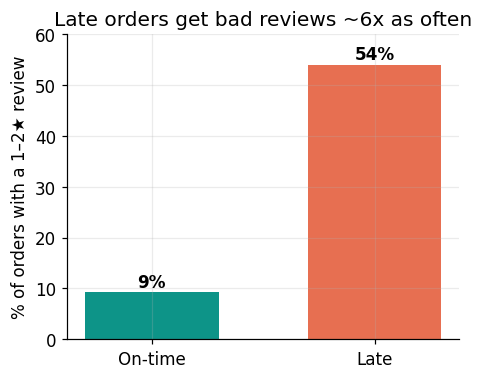

In [2]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
late,ont=df[df.is_late==1],df[df.is_late==0]
counts=[late.is_low.sum(),ont.is_low.sum()]; nobs=[len(late),len(ont)]
z,p=proportions_ztest(counts,nobs); lo,hi=confint_proportions_2indep(counts[0],nobs[0],counts[1],nobs[1])
rates=[counts[1]/nobs[1],counts[0]/nobs[0]]
print(f"low-review rate  |  on-time={rates[0]:.1%}   late={rates[1]:.1%}")
print(f"difference={rates[1]-rates[0]:.1%}  95% CI[{lo:.1%},{hi:.1%}]  z={z:.1f}  p={p:.1e}")

fig,ax=plt.subplots(figsize=(4.6,3.6))
ax.bar(['On-time','Late'],[rates[0]*100,rates[1]*100],color=[TEAL,'#e76f51'],width=.6)
for i,v in enumerate([rates[0],rates[1]]): ax.text(i,v*100+1,f'{v:.0%}',ha='center',fontweight='bold')
ax.set_ylabel('% of orders with a 1–2★ review'); ax.set_title('Late orders get bad reviews ~6x as often'); ax.set_ylim(0,60); plt.show()

The gap is huge and highly significant, but this does not yet prove *cause*. Late orders might differ in other ways. Next we control for those.

## 2. Logistic regression — does it survive controls?

We model the probability of a 1–2 star review from **is_late** plus confounders (price, freight, item count, estimated delivery days). If the effect were just those confounders, the `is_late` odds ratio would collapse toward 1.

Odds ratio for LATE = 13.0  (95% CI 12.4-13.7),  p=0.0e+00


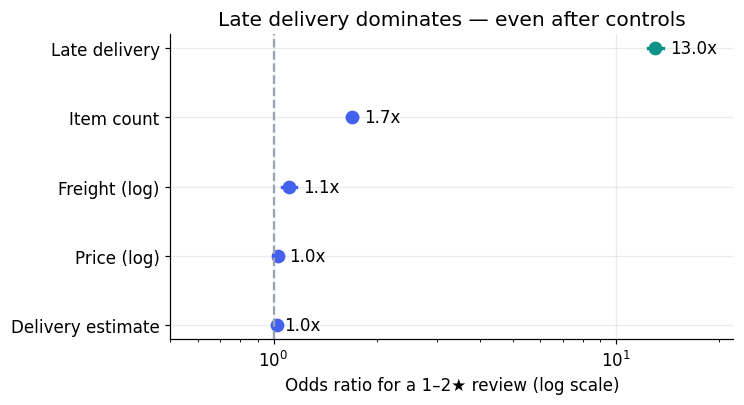

In [3]:
import statsmodels.formula.api as smf
m=smf.logit('is_low ~ is_late + log_price + log_freight + n_items + est_days',data=df).fit(disp=0)
terms=['is_late','n_items','log_freight','log_price','est_days']
labels={'is_late':'Late delivery','n_items':'Item count','log_freight':'Freight (log)','log_price':'Price (log)','est_days':'Delivery estimate'}
ors=np.exp(m.params[terms]); ci=np.exp(m.conf_int().loc[terms]); order=ors.sort_values().index
print(f"Odds ratio for LATE = {ors['is_late']:.1f}  (95% CI {ci.loc['is_late'][0]:.1f}-{ci.loc['is_late'][1]:.1f}),  p={m.pvalues['is_late']:.1e}")

fig,ax=plt.subplots(figsize=(6.6,3.6))
for i,t in enumerate(order):
    lo2,hi2=ci.loc[t]; col=TEAL if t=='is_late' else BLUE
    ax.plot([lo2,hi2],[i,i],color=col,lw=2.2); ax.plot(ors[t],i,'o',color=col,ms=8)
    ax.text(hi2*1.05,i,f'{ors[t]:.1f}x',va='center')
ax.axvline(1,ls='--',color=GREY); ax.set_yticks(range(len(order))); ax.set_yticklabels([labels[t] for t in order])
ax.set_xscale('log'); ax.set_xlabel('Odds ratio for a 1–2★ review (log scale)')
ax.set_title('Late delivery dominates — even after controls'); ax.set_xlim(.5,ci.values.max()*1.6); plt.show()

**The effect survives.** Controlling for the obvious confounders, late delivery still multiplies the odds of a bad review about 13x. That is strong, defensible evidence that the delivery experience itself, not just correlated factors, drives dissatisfaction.

## 3. What drives a bad review? — Random Forest

A predictive model to rank the drivers and sanity-check the story.

Test AUC = 0.720


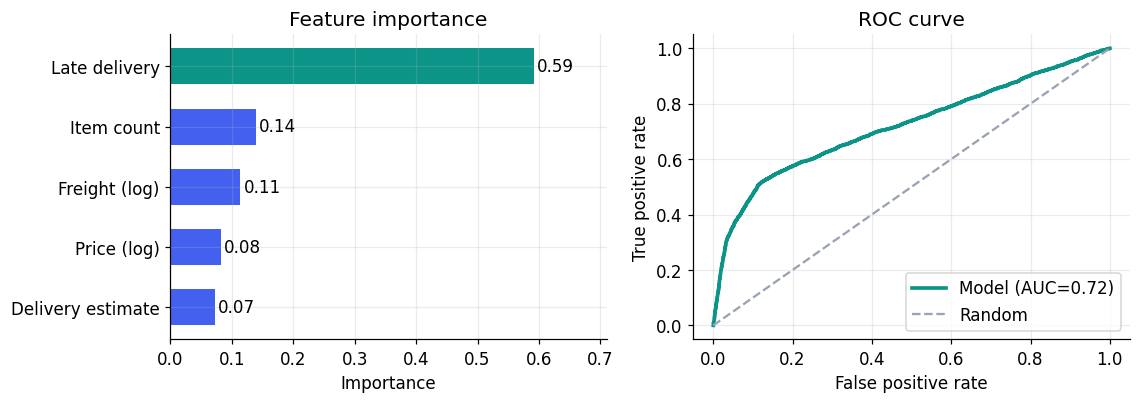

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
feats=['is_late','log_price','log_freight','n_items','est_days']
X,y=df[feats],df['is_low']
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.25,random_state=42,stratify=y)
rf=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,n_jobs=-1,class_weight='balanced').fit(Xtr,ytr)
proba=rf.predict_proba(Xte)[:,1]; auc=roc_auc_score(yte,proba)
imp=pd.Series(rf.feature_importances_,index=feats).sort_values()
print(f"Test AUC = {auc:.3f}")

fig,axes=plt.subplots(1,2,figsize=(10.5,3.8))
cols=[TEAL if f=='is_late' else BLUE for f in imp.index]
axes[0].barh([labels[f] for f in imp.index],imp.values,color=cols,height=.6)
for i,v in enumerate(imp.values): axes[0].text(v+.005,i,f'{v:.2f}',va='center')
axes[0].set_xlim(0,imp.values.max()*1.2); axes[0].set_title('Feature importance'); axes[0].set_xlabel('Importance')
fpr,tpr,_=roc_curve(yte,proba)
axes[1].plot(fpr,tpr,color=TEAL,lw=2.4,label=f'Model (AUC={auc:.2f})'); axes[1].plot([0,1],[0,1],'--',color=GREY,label='Random')
axes[1].set_xlabel('False positive rate'); axes[1].set_ylabel('True positive rate'); axes[1].set_title('ROC curve'); axes[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

## Conclusion & recommendations

**What the data says**
- Late delivery is the single biggest, most *controllable* driver of bad reviews: after controlling for price, freight, item count, and delivery estimate, a late order still has ~**13x the odds** of a 1–2★ review, and the model ranks it the top driver.
- **~97% of customers never return**, so the first delivery largely decides customer value.
- Revenue is concentrated: the top 20% of sellers drive ~**82%** of GMV.

**Recommendations for the marketplace**
1. **Under-promise delivery dates.** Add a buffer to the estimate shown at checkout so fewer orders arrive "late vs promise." Validate with the A/B test in `EXPERIMENT_DESIGN.md`, watching checkout conversion as a guardrail.
2. **Proactive delay alerts.** When an order is flagged likely-late, notify the customer early (optionally with a small credit) to soften the review hit.
3. **Fix the worst routes and categories first.** Focus logistics/SLA effort where late rates are highest for the biggest marginal gain.
4. **Protect the top sellers.** Since 20% of sellers drive 82% of revenue, prioritize their fulfillment reliability, their late orders do the most damage.
5. **Win the second order.** With a one-and-done customer base, a post-first-purchase retention nudge (follow-up plus a reorder incentive after a good delivery) is the clearest lever on lifetime value.